<h1>High-Frequency Gravitational Wave Limits from Precision Spectroscopy</h1>

Dmitry Budker, Valerie Domcke, Joachim Kopp, Oleg Tretiak<br>
arXiv:2607.YYYYY<br>
jkopp@uni-mainz.de

## Usage Information

<h3>License</h3>

Copyright (C) 2019 Joachim Kopp (jkopp@cern.ch), Toby Opferkuch (tobyopferkuch@lbl.gov), Edward Wang (edward.wang@tum.de)

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program.  If not, see <https://www.gnu.org/licenses/>.

<h3>Overview</h3>

This code produces the data for the red curves in fig. 2 of the paper. The figure itself has been produced using a modified version of HFGWPlotter.
HFGWPlotter has been developed by Francesco Muia, Andreas Ringwald and Carlos Tamarit, https://github.com/ctamaritd/HFGWPlotter_Sh.

## Initialization

In [1]:
%autosave 0
import os, sys, glob
import copy
import re
import fileinput, pickle
import string, array
import itertools
import numpy as np
import numpy.random as rnd
import numpy.linalg as linalg
import scipy.interpolate as interp
import scipy.integrate as integ
import scipy.fft as fft
import scipy.optimize as opt
import scipy.special as sf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cbook
import labellines as ll
import warnings
#warnings.filterwarnings("ignore", category=matplotlib.cbook.mplDeprecation)

# Directories
base_dir = os.path.expanduser("~/Dropbox/hf-gw-spectroscopy/jk/public/")
os.chdir(base_dir)

# Set up matplotlib
%matplotlib inline
mpl.rcParams['text.usetex']    = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb,siunitx}'
mpl.rcParams['font.family']    = 'serif'
mpl.rcParams['font.size']      = '14'
mpl.rcParams['figure.figsize'] = 6.4, 4.8

# Unit conversion and physical constants
class my_units:
    # Energy and mass
    eV    = 1.
    keV   = 1.e3
    MeV   = 1.e6
    GeV   = 1.e9
    TeV   = 1.e12
    PeV   = 1.e15
    kg    = 5.62e35*eV
    grams = 0.001*kg
    
    # Length and time
    m     = 5.076e6
    meter = m
    km    = 1000*m
    cm    = 0.01*m
    nm    = 1.e-9*m
    fm    = 1.e-15*m
    AU    = 1.4960e11*m
    pc    = 30.857e15*m
    kpc   = 1.e3*pc
    Mpc   = 1.e6*pc
    Gpc   = 1.e9*pc
    ly    = 9460730472580800*m  # light year
    sec   = 1.523e15
    hrs   = 3600*sec
    days  = 24*hrs
    yrs   = 365*days,
    Hz    = 1./sec
    kHz   = 1.e3*Hz
    MHz   = 1.e6*Hz
    GHz   = 1.e9*Hz
    THz   = 1.e12*Hz
    
    barn  = 1.e-24*cm**2
    pb    = 1.e-36*cm**2
    fb    = 1.e-39*cm**2

    Watt = 6.2415e18*eV/sec
    
    # Various astrophysical constants
    GN    = 6.708e-39/1e18  # eV^-2, Newton's constant
    MPl   = 1.22093e19*GeV   # Planck mass, PDG 2013
    Msun  = 1.989e30*kg
    Rsun  = 6.9551e8*meter
    
    # cosmology
    h       = 0.688                          # according to Planck, see Wikipedia; HE97
    H0      = h * 100. * km / sec/ Mpc       # Hubble parameter
    rho_c0  = 3. * H0**2/(8. * np.pi * GN)   # critical density today, Kolb Turner eq. (3.14)
    Omega_m = 0.14 / h**2                    # total matter density
    
    # particle physics
    alpha_em = (1./137.035999139)            # electromagnetic fine structure constant (PDG 2018)
    m_e      = 0.5109989461 * MeV            # electron mass (PDG 2018)
    m_mu     = 105.6583745 * MeV             # muon mass (PDG 2018)
    m_tau    = 1776.86 * MeV                 # tau mass (PDG 2018)
    m_p      = 938.2720813 * MeV             # proton mass (PDG 2018)
    m_n      = 939.565413 * MeV              # neutron mass (PDG 2018)
    m_u      = 931.4940954 * MeV             # atomic mass unit (PDG 2018)
    m_pi0    = 134.9768 * MeV                # neutral pion mass (PDG 2020)
    tau_mu   = 2.1969811e-6 * sec            # muon lifetime (PDG 2018)
    
    # PDG codes
    pdg_nu_e   = 12
    pdg_nu_mu  = 14
    pdg_nu_tau = 16
    pdg_e      = 11
    pdg_mu     = 13
    pdg_tau    = 15
    pdg_gamma  = 22
    pdg_pip    = 211
    pdg_pi0    = 111
    pdg_KL     = 130
    pdg_Kp     = 321
    pdg_Ds     = 431

u = my_units()

Autosave disabled


In [2]:
def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

def adjust_saturation(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], c[1], max(0, min(1, amount * c[2])))


## Sensitivity Studies

In [ ]:
def h_of_dw(dw_over_w, wg, X, k_gw, phi0=None, L_laser=10*u.cm):
    """Convert a frequency shift sensitivity to a strain sensitivity, taking
       into account the effect of the GW on both photon propagation and on
       the laser cavity.

    Arguments:
        dw_over_w: relative frequency shift sensitivity
        wg:        gravitational wave angular frequency; scalar or array with
                   shape broadcastable with the leading dimensions of X
        X:         array of displacement vectors describing the segments of the
                   photon path. Shape (..., n_segments, 3), where:
                   - leading dimensions (...) can represent, e.g., different values
                     of wg or different GW propagation directions to be iterated
                     over, and must be broadcastable with wg, k_gw, and phi0,
                   - the second-to-last dimension n_segments indexes path segments,
                   - the last dimension holds the three Cartesian components of each
                     segment vector (displacement from segment start to segment end).
        k_gw:      GW propagation direction (need not be normalised); shape (3,)
                   or (..., 3) broadcastable with the leading dimensions of X
        phi0:      GW phase at the time and position the photon is emitted; scalar
                   or array broadcastable with the leading dimensions of X.
                   If None, use the optimal phi0, i.e. the one where the modulation
                   amplitude is largest. (This works only if the photon path X has only
                   one segment, otherwise determining the optimal phi0 is difficult.
                   For multi-segment paths, the function throws an error if phi0 is None.)
        L_laser:  length of the laser cavity (needed for computing the effect of the GW
                   on the laser cavity)

    Returns:
        strain sensitivity h, with shape determined by broadcasting the leading
        dimensions of X, wg, k_gw, and phi0 (the n_segments and xyz axes are
        contracted out by summation over segments).

    Raises:
        ValueError (from numpy) if input shapes are not broadcastable.
    """
    wg     = np.asarray(wg)[..., None]                             # add segment broadcast dimension -> (n_freq, n_segments)
    k_gw_norm = k_gw / linalg.norm(k_gw, axis=-1)[..., None]
    L      = linalg.norm(X, axis=-1)                               # (..., n_segments)
    X_norm = X / L[..., None]                                      # (..., n_segments, 3)
    theta  = np.arccos(k_gw_norm @ np.swapaxes(X_norm, -1, -2))    # (..., n_segments), remember that "@" contracts with the second-to-last axis of the second operand

    # frequency shift response: cavity contribution (segment 0 only) and per-segment propagation contribution
    # _f_laser  = lambda p, wg_s, th_s: (
    #     1/(4*L_cavity*wg_s) * (
    #         (1+np.cos(th_s))*np.sin(p - L_cavity*wg_s)
    #       - (1-np.cos(th_s))*np.sin(p + L_cavity*wg_s)
    #       - 2*np.cos(th_s) *np.sin(p - L_cavity*wg_s*np.cos(th_s))
    #     )
    # )
    _f_laser  = lambda p, wg_s, th_s: (
          1/(4*L_laser*wg_s) * (
              (np.cos(th_s) - 1)*np.sin(p + 2*L_laser*wg_s)
            + (np.cos(th_s) + 1)*np.sin(p)
            - 2*np.cos(th_s)*np.sin(p + L_laser*wg_s*(1 - np.cos(th_s)))
          ) )

    # frequency shift during propagation
    _f_prop = lambda p, wg_s, th_s, L_s: 0.5*(1+np.cos(th_s))*(np.cos(p) - np.cos(wg_s*L_s*(1-np.cos(th_s))+p))

    # determine optimal GW phase if phi0 not given
    if phi0 is None:
        if X.shape[-2] != 1:
            raise ValueError("Determining the optimal phi0 is only implemented for single-segment paths.")
        
        # choose GW phase such that the modulation amplitude is maximal;
        # for a single segment phi[...,0] = phi0, so minimize h directly over phi0.
        wg_0, theta_0, L_0 = wg[..., 0], theta[..., 0], L[..., 0]
        phi0 = np.vectorize(lambda wg_s, th_s, L_s: opt.minimize(
            lambda p: -abs(_f_laser(p[0], wg_s, th_s) + _f_prop(p[0], wg_s, th_s, L_s)),
            x0=[0.]
        ).x[0])(wg_0, theta_0, L_0)[..., None]
    else:
        phi0 = np.asarray(phi0)[..., None]

    # cumulative travel time and GW phase offset at the start of each segment
    # (prepend zero for the first segment, drop the last entry)
    LL = np.concatenate((np.zeros(L.shape[:-1] + (1,)), L[..., :-1]), axis=-1)  # (..., n_segments)
    XX = np.concatenate((np.zeros(X.shape[:-2] + (1,) + X.shape[-1:]), X[..., :-1, :]), axis=-2)  # (..., n_segments, 3)

    # array shape is (number of frequencies, number of random directions, number of segments)
    phi = phi0 + wg * (np.cumsum(LL, axis=-1) - np.cumsum(k_gw_norm @ np.swapaxes(XX, -1, -2), axis=-1))
    return dw_over_w / np.abs(
        _f_laser(phi[...,0], wg[...,0], theta[...,0])                        # effect on the laser cavity
        + np.sum(_f_prop(phi, wg, theta, L), axis=-1)                      # effect on photon propagation
    )

def h_of_dw_expB(dw_over_w, wg, k_gw, phi0=None, L_cavity=10*u.cm):
    """Convert a frequency shift sensitivity to a strain sensitivity
       for Experiment B from https://arxiv.org/abs/2201.02042.

    Arguments:
        dw_over_w: relative frequency shift sensitivity
        wg:        gravitational wave angular frequency
        k_gw:      propagation direction of the GW in the experiment's coordinate
                   system (need not be normalised)
        phi0:      GW phase at the time the photon is emitted

    Returns:
        strain sensitivity h, with shape determined by broadcasting dw_over_w,
        wg, the leading dimensions of k_gw, and phi0.

    Raises:
        ValueError (from numpy) if input shapes are not broadcastable.
    """
    # the path the photon takes through the setup. Shape (n_segments=3, 3)
    # X_table = np.array([[100.,   0., 0.],
    #                     [  0., -50., 0.],
    #                     [-50.,   0., 0.]]) * u.cm
    X_table = np.array([[100., 0., 0.]]) * u.cm
        # we agreed on this simplified geometry on 2026-06-02. It should be a conservative proxy
        # for the real photon path, which is impossible to reconstruct, given that the experiment
        # has been dismantled since.

    return h_of_dw(dw_over_w, wg, X_table, k_gw, phi0=phi0, L_laser=L_cavity)


def h_of_dw_expA(dw_over_w, wg, k_gw, phi0=None, L_cavity=10*u.cm):
    """Convert a frequency shift sensitivity to a strain sensitivity
       for Experiment A from https://arxiv.org/abs/2201.02042.

    Arguments:
        dw_over_w: relative frequency shift sensitivity
        wg:        gravitational wave angular frequency
        k_gw:      propagation direction of the GW in the experiment's coordinate
                   system (need not be normalised)
        phi0:      GW phase at the time the photon is emitted

    Returns:
        strain sensitivity h, with shape determined by broadcasting dw_over_w,
        wg, the leading dimensions of k_gw, and phi0.

    Raises:
        ValueError (from numpy) if input shapes are not broadcastable.
    """
    # the path the photon takes through the setup. Shape (n_segments=3, 3)
    X_table = np.array([[100., 0., 0.]]) * u.cm
        # we agreed on this simplified geometry on 2026-06-02. It should be a conservative proxy
        # for the real photon path, which is impossible to reconstruct, given that the experiment
        # has been dismantled since.

    return h_of_dw(dw_over_w, wg, X_table, k_gw, phi0=phi0, L_laser=L_cavity)


def h_of_dw_future_res(dw_over_w, wg, L_laser = 10*u.cm):
    """Convert a frequency shift sensitivity to a strain sensitivity
       for a possible future upgrade of Experiment B
       from https://arxiv.org/abs/2201.02042. We assume the laser is followed
       by an L-shaped cavity, with the GW perfectly on resonance.

    Arguments:
        dw_over_w: relative frequency shift sensitivity
        wg:        gravitational wave angular frequency
        L_laser:   length of the laser cavity
    Returns:
        strain sensitivity h, with the same shape as wg.

    Raises:
        ValueError (from numpy) if input shapes are not broadcastable.
    """

    
    X      = np.array([[100., 0., 0.]]) * u.cm                     # free propagation distance
    k_gw   = np.array([0,0,-1])                                    # GW propagation direction
    wg     = np.asarray(wg)[..., None]                             # add segment broadcast dimension -> (n_freq, n_segments)
    k_gw_norm = k_gw / linalg.norm(k_gw, axis=-1)[..., None]
    L      = linalg.norm(X, axis=-1)                               # (..., n_segments)
    X_norm = X / L[..., None]                                      # (..., n_segments, 3)
    theta  = np.arccos(k_gw_norm @ np.swapaxes(X_norm, -1, -2))    # (..., n_segments), remember that "@" contracts with the second-to-last axis of the second operand

    # frequency shift response: laser cavity contribution (segment 0 only) and per-segment propagation contribution
    _f_laser  = lambda p, wg_s, th_s: (
          1/(4*L_laser*wg_s) * (
              (np.cos(th_s) - 1)*np.sin(p + 2*L_laser*wg_s)
            + (np.cos(th_s) + 1)*np.sin(p)
            - 2*np.cos(th_s)*np.sin(p + L_laser*wg_s*(1 - np.cos(th_s)))
          ) )
    
    # frequency shift during propagation
    _f_prop   = lambda p, wg_s, th_s, L_s: 0.5*(1+np.cos(th_s))*(np.cos(p) - np.cos(wg_s*L_s*(1-np.cos(th_s))+p))

    # frequency shift in the L-shaped cavity
    _f_etalon = lambda p, wg, th: (
        1/(2*np.pi) * (
              2*np.cos(th/2)**2 * np.sin(np.pi/4*(np.cos(th) - 1)) * (np.cos(p - np.pi/4*(1 + np.cos(th))) - np.sin(p - np.pi/4*(1 + np.cos(th))))
            + (1 - np.sin(th)) * np.sin(np.pi/4*(1 + np.sin(th)))  * (np.cos(p + np.pi/4*(1 + np.sin(th))) + np.sin(p + np.pi/4*(1 + np.sin(th))))
        ) )

    # choose GW phase such that the modulation amplitude is maximal;
    # for a single segment phi[...,0] = phi0, so minimize h directly over phi0.
    wg_0, theta_0, L_0 = wg[..., 0], theta[..., 0], L[..., 0]
    phi0 = np.vectorize(lambda wg_s, th_s, L_s: opt.minimize(
        lambda p: -abs(_f_laser(p[0], wg_s, th_s) + _f_prop(p[0], wg_s, th_s, L_s) + _f_etalon(p[0], wg_s, th_s)),
        x0=[0.]
    ).x[0])(wg_0, theta_0, L_0)[..., None]

    # cumulative travel time and GW phase offset at the start of each segment
    # (prepend zero for the first segment, drop the last entry)
    LL = np.concatenate((np.zeros(L.shape[:-1] + (1,)), L[..., :-1]), axis=-1)  # (..., n_segments)
    XX = np.concatenate((np.zeros(X.shape[:-2] + (1,) + X.shape[-1:]), X[..., :-1, :]), axis=-2)  # (..., n_segments, 3)

    # array shape is (number of frequencies, number of random directions, number of segments)
    phi = phi0 + wg * (np.cumsum(LL, axis=-1) - np.cumsum(k_gw_norm @ np.swapaxes(XX, -1, -2), axis=-1))
    return dw_over_w / np.abs(
        _f_laser(phi[...,0], wg[...,0], theta[...,0])                      # effect on the laser cavity
        + np.sum(_f_prop(phi, wg, theta, L), axis=-1)                      # effect on photon propagation
        + _f_etalon(phi[...,0], wg[...,0], theta[...,0])                   # effect on the etalon
    )


future sensitivity (bb): h <  1.461897006338975e-20  sqrt(S_h) <  1.1994684537029606e-17
future sensitivity (res): h <  8.405316808386859e-26  sqrt(S_h) <  6.896458718584695e-23


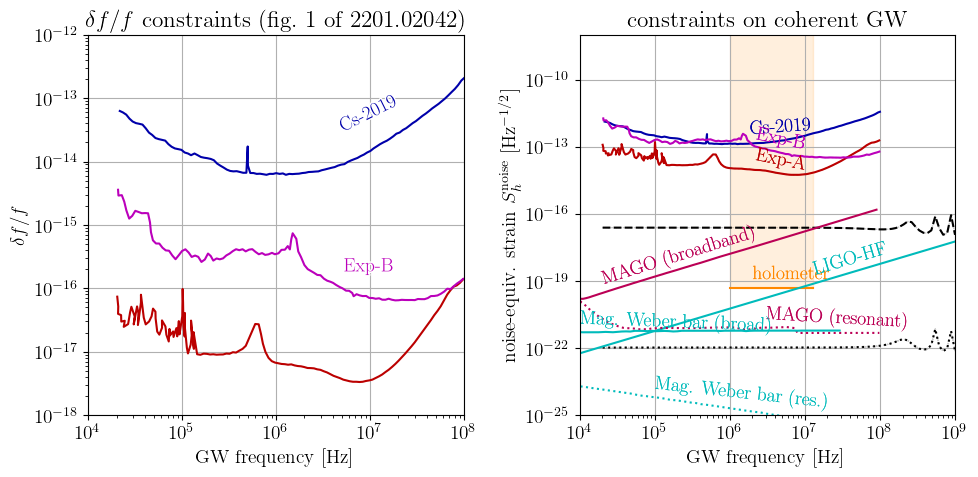

In [ ]:
# constraints on \delta f / f from https://arxiv.org/abs/2201.02042, fig. 1
df_over_f = { 'Cs-2019': np.loadtxt('data/2201.02042-fig-1-Cs-2019.csv', delimiter=','),
              'Exp-A':   np.loadtxt('data/2201.02042-fig-1-Exp-A.csv',   delimiter=','),
              'Exp-B':   np.loadtxt('data/2201.02042-fig-1-Exp-B.csv',   delimiter=',') }
#df_over_f = { 'Exp-B':   np.loadtxt('data/2201.02042-fig-1-Exp-B.csv',   delimiter=',') }
for k in df_over_f:
    df_over_f[k][:,0] *= u.Hz
    
# integration time
t_int = { 'Cs-2019': 110 * u.sec,         # see https://arxiv.org/abs/1905.02968: 5 ms * 22,000
          'Exp-A':   187 * u.hrs,         # appendix D
          'Exp-B':   18 * u.hrs }         # appendix A

my_colors = { 'Cs-2019': '#0000aa',
              'Exp-A':   '#bb0000',
              'Exp-B':   '#bb00bb'
            }
my_ls = { 'Cs-2019': '-',
          'Exp-A':   '-',
          'Exp-B':   '-'
        }

# Future sensitivities
t_int['future-bb']      = t_int['Exp-A']
t_int['future-res']     = t_int['Exp-A']
my_colors['future-bb']  = 'k'
my_colors['future-res'] = 'k'
my_ls['future-bb']      = '--'
my_ls['future-res']     = ':'

# estimate future sensitivity based on eq. (9) from the draft
sens_future_bb = 6.8e-19 * (5.5*u.MHz/u.GHz) * np.sqrt(1e15*u.Hz/(3.5e14*u.Hz)) * np.sqrt(1*u.Watt/(0.01*u.Watt)) * np.sqrt(10*u.hrs/(t_int['future-bb']))
print('future sensitivity (bb): h < ', sens_future_bb, ' sqrt(S_h) < ', sens_future_bb * np.sqrt(t_int['future-bb']/u.sec))
sens_future_res = 6.8e-19 * (1*u.kHz/u.GHz) * np.sqrt(1e15*u.Hz/(3.5e14*u.Hz)) * np.sqrt(1*u.Watt/(10*u.Watt)) * np.sqrt(10*u.hrs/(t_int['future-res']))
print('future sensitivity (res): h < ', sens_future_res, ' sqrt(S_h) < ', sens_future_res * np.sqrt(t_int['future-res']/u.sec))

df_over_f['future-bb']  = np.concatenate( (df_over_f['Exp-A'],
                                           np.array([np.logspace(8, 9, 20)*u.Hz, np.full(20, 0.)]).T ), axis=0)
df_over_f['future-bb'][:,1] = np.full(len(df_over_f['future-bb']), sens_future_bb)   # eq. 5 in the draft with P=10 mW, \sigma_\gamma=5.5 MHz, \omega_\gamma=2.2e15 Hz
df_over_f['future-res'] = df_over_f['future-bb'].copy()
df_over_f['future-res'][:,1] = np.full(len(df_over_f['future-res']), sens_future_res)

# external limits (noise-equivalent strain PSD; from Valerie's sensitivities_v2.nb, 25 Jan 2025)
import json
with open("data/external-limits.json", "r") as f:
    lim = json.load(f)
for k in lim:
    lim[k] = np.array(lim[k])
    lim[k][:,0] *= u.Hz
    lim[k][:,1] *= 1/np.sqrt(u.Hz)

    
fig = plt.figure(figsize=(10,5))
ax = plt.subplot(121)
for k in df_over_f:
    ax.plot(df_over_f[k][:,0]/u.Hz, df_over_f[k][:,1], color=my_colors[k], label=k)
for j in range(len(df_over_f)):
    ll.labelLine(ax.get_lines()[j], x=1e7, yoffset=0.6, yoffset_logspace=True, zorder=2.5, outline_width=2, fontfamily='serif')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e4, 1e8)
ax.set_ylim(1e-18, 1e-12)
ax.set_xlabel('GW frequency [Hz]')
ax.set_ylabel('$\delta f / f$')
ax.set_title('$\delta f / f$ constraints (fig.~1 of 2201.02042)')
ax.grid()
#ax.legend(loc='upper right')

ax = plt.subplot(122)
for k in df_over_f:
    # compute bands indicating the variation in the limit depending on the GW direction and phase
    if 'future-res' in k:
        h_table = h_of_dw_future_res(df_over_f[k][:,1,None], wg=2*np.pi*df_over_f[k][:,0,None])
    else:
        # n_rnd = 1000  # number of random GW directions/phases
        # cos_theta_table = 2*rnd.rand((n_rnd)) - 1
        # sin_theta_table = np.sqrt(np.fmax(0., 1 - cos_theta_table**2))
        # phi_table       = 2*np.pi * rnd.rand((n_rnd))

        cos_theta_table = np.array([1.])
        sin_theta_table = np.sqrt(np.fmax(0., 1 - cos_theta_table**2))
        phi_table       = np.array([0.])
        k_gw_table      = np.array([sin_theta_table*np.cos(phi_table), sin_theta_table*np.sin(phi_table), cos_theta_table]).T
        if 'Exp-A' in k:
            h_table = h_of_dw_expA(df_over_f[k][:,1,None], wg=2*np.pi*df_over_f[k][:,0,None],
                                   k_gw=k_gw_table[None,:,:])
        elif 'Exp-B' in k:
            h_table = h_of_dw_expB(df_over_f[k][:,1,None], wg=2*np.pi*df_over_f[k][:,0,None],
                                   k_gw=k_gw_table[None,:,:])
        else:
            X = np.array([[1., 0., 0.]]) * u.meter  # photon travels 1 m in x-direction; shape (n_segments=1, 3)
            h_table = h_of_dw(df_over_f[k][:,1,None], wg=2*np.pi*df_over_f[k][:,0,None],
                              X=X, k_gw=k_gw_table[None,:,:])
    h_med = np.median(h_table, axis=-1)

    # plot
    h_lo = np.quantile(h_table, 0.16, axis=-1)
    h_hi = np.quantile(h_table, 0.84, axis=-1)
    ax.fill_between(df_over_f[k][:,0]/u.Hz, h_lo*np.sqrt(t_int[k]/u.sec), h_hi*np.sqrt(t_int[k]/u.sec), color=my_colors[k], alpha=0.2, ls=':')
    ax.plot(df_over_f[k][:,0]/u.Hz, h_med*np.sqrt(t_int[k]/u.sec), color=my_colors[k], ls=my_ls[k], label=k)
#    ax.plot(df_over_f[k][:,0]/u.Hz, h_of_dw(df_over_f[k][:,1], wg=2*np.pi*df_over_f[k][:,0], L=1*u.meter, theta=90*np.pi/180., phi0=0.),
#            color=my_colors[k], label=k)
    ll.labelLine(ax.get_lines()[-1], x=5e6, yoffset=0.6, yoffset_logspace=True, zorder=2.5, outline_width=0, fontfamily='serif')

    # export for HFGW plotter
    # np.savetxt('sensitivity-curve-'+k+'.csv', np.array([df_over_f[k][:,0]/u.Hz, h_med*np.sqrt(t_int[k]/u.sec)]).T,
    #            fmt='%.5g', delimiter=',')
    np.savetxt('sensitivity-curve-'+k+'.csv', np.array([df_over_f[k][:,0]/u.Hz, h_lo*np.sqrt(t_int[k]/u.sec),
                                                        h_med*np.sqrt(t_int[k]/u.sec), h_hi*np.sqrt(t_int[k]/u.sec)]).T,
               fmt='%.5g', delimiter=',')

# external limits
ax.plot(lim['HolometerSingle'][:,0]/u.Hz, lim['HolometerSingle'][:,1]*np.sqrt(u.Hz), color='#ff8800', label='holometer')
ax.fill_between(lim['HolometerSingle'][:,0]/u.Hz, lim['HolometerSingle'][:,1]*np.sqrt(u.Hz), 1, color='#ff880022')
ax.plot(lim['LIGOHF'][:,0]/u.Hz,      lim['LIGOHF'][:,1]*np.sqrt(u.Hz),      color='#00bbbb', label='LIGO-HF')
ax.plot(lim['MAGObroad'][:,0]/u.Hz,   lim['MAGObroad'][:,1]*np.sqrt(u.Hz),   color='#bb0055', label='MAGO (broadband)')
ax.plot(lim['MAGOsres'][:,0]/u.Hz,    lim['MAGOsres'][:,1]*np.sqrt(u.Hz),    color='#bb0055', ls=':', label='MAGO (resonant)')
ax.plot(lim['MWBDMRbroad'][:,0]/u.Hz, lim['MWBDMRbroad'][:,1]*np.sqrt(u.Hz), color='#00bbbb', label='Mag. Weber bar (broad)')
ax.plot(lim['MWBDMRres'][:,0]/u.Hz,   lim['MWBDMRres'][:,1]*np.sqrt(u.Hz),   color='#00bbbb', ls=':', label='Mag. Weber bar (res.)')
label_x = [2e6, 1.3e7, 2e4, 3e6, 1e4, 1e5]
for this_x, this_curve in zip(label_x, ax.get_lines()[-6:]):
    this_curve._y *= 1e10  # matplotlib-label-lines cannot handle small number ...
    this_label = ll.labelLine(this_curve, x=this_x, yoffset=0.6, yoffset_logspace=True, zorder=2.5, ha='left', outline_width=0, fontfamily='serif')
    this_curve._y *= 1e10
    this_label._y *= 1e-10

# plot beautification
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e4, 1e9)
ax.set_ylim(1e-25, 1e-8)
ax.set_xlabel('GW frequency [Hz]')
ax.set_ylabel(r'noise-equiv. strain $S_h^\text{noise}$ [Hz$^{-1/2}$]')
# ax.annotate('bands: GW direction ($1\sigma$)', (0.98,0.97), xycoords='axes fraction', ha='right', va='top',
#             bbox=dict(boxstyle='square,pad=0', fc='#ffffffbb', ec='none'))
ax.set_title('constraints on coherent GW')
ax.grid()

plt.tight_layout()
#plt.savefig('h-vs-f.pdf')
plt.show()
